<a href="https://colab.research.google.com/github/Al-Rouman/Convolutional-Neural-Network-CNN-/blob/main/223002036_Al_Rouman_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
files.upload() # Upload your kaggle.json file here

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rz8pro","key":"323e45abb1d5854b49c4e35740c84a8b"}'}

In [ ]:
!pip install -q kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download and unzip the dataset
!kaggle datasets download -d msambare/fer2013
!unzip -q fer2013.zip -d dataset/

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
100% 60.3M/60.3M [00:00<00:00, 135MB/s]



In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

train_dir = 'dataset/train'
test_dir = 'dataset/test'

batch_size = 64
img_size = 48

# Aggressive augmentation for the training data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Only rescale the validation/test data!
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)


Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, BatchNormalization
from tensorflow.keras.optimizers import Adam

num_classes = 7

model = Sequential()

# Block 1
model.add(Conv2D(64, (3, 3), padding='same', activation='relu', input_shape=(48, 48, 1)))
model.add(BatchNormalization())
model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Block 2
model.add(Conv2D(128, (5, 5), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(128, (5, 5), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Block 3
model.add(Conv2D(256, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(256, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Block 4
model.add(Conv2D(512, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(512, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Fully Connected Layer
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(num_classes, activation='softmax'))

# Compile
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 7,581,127 (28.92 MB)

 Trainable params: 7,575,751 (28.90 MB)

 Non-trainable params: 5,376 (21.00 KB)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Callbacks
checkpoint = ModelCheckpoint('best_fer_model.h5', monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')

early_stopping = EarlyStopping(monitor='val_loss', patience=15, verbose=1, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, verbose=1, min_lr=1e-6)

callbacks_list = [checkpoint, early_stopping, reduce_lr]

# Train the model (Make sure you have selected a T4 GPU in Colab: Runtime -> Change runtime type)
epochs = 60

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.n // train_generator.batch_size,
    epochs=epochs,
    validation_data=test_generator,
    validation_steps=test_generator.n // test_generator.batch_size,
    callbacks=callbacks_list
)

Epoch 1/60
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.1894 - loss: 2.4910
Epoch 1: val_accuracy improved from None to 0.21401, saving model to best_fer_model.h5



Epoch 1: finished saving model to best_fer_model.h5
448/448 ━━━━━━━━━━━━━━━━━━━━ 76s 112ms/step - accuracy: 0.2082 - loss: 2.2087 - val_accuracy: 0.2140 - val_loss: 1.8451 - learning_rate: 0.0010
Epoch 2/60
  1/448 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.2188 - loss: 1.9300

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.21401
448/448 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.2188 - loss: 1.9300 - val_accuracy: 0.2088 - val_loss: 1.8443 - learning_rate: 0.0010
Epoch 3/60
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.2694 - loss: 1.8606
Epoch 3: val_accuracy improved from 0.21401 to 0.39411, saving model to best_fer_model.h5



Epoch 3: finished saving model to best_fer_model.h5
448/448 ━━━━━━━━━━━━━━━━━━━━ 32s 71ms/step - accuracy: 0.3003 - loss: 1.7878 - val_accuracy: 0.3941 - val_loss: 1.6110 - learning_rate: 0.0010
Epoch 4/60
  1/448 ━━━━━━━━━━━━━━━━━━━━ 20s 45ms/step - accuracy: 0.2344 - loss: 1.8120
Epoch 4: val_accuracy did not improve from 0.39411
448/448 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2344 - loss: 1.8120 - val_accuracy: 0.3797 - val_loss: 1.6213 - learning_rate: 0.0010
Epoch 5/60
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.3918 - loss: 1.5873
Epoch 5: val_accuracy improved from 0.39411 to 0.47810, saving model to best_fer_model.h5


...


Epoch 49: finished saving model to best_fer_model.h5
448/448 ━━━━━━━━━━━━━━━━━━━━ 33s 73ms/step - accuracy: 0.6889 - loss: 0.8387 - val_accuracy: 0.6650 - val_loss: 0.9120 - learning_rate: 8.0000e-06
Epoch 50/60
  1/448 ━━━━━━━━━━━━━━━━━━━━ 22s 51ms/step - accuracy: 0.6562 - loss: 0.8772
Epoch 50: val_accuracy did not improve from 0.66504
448/448 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.6562 - loss: 0.8772 - val_accuracy: 0.6650 - val_loss: 0.9122 - learning_rate: 8.0000e-06
Epoch 51/60
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.6934 - loss: 0.8270
Epoch 51: val_accuracy improved from 0.66504 to 0.66588, saving model to best_fer_model.h5



Epoch 51: finished saving model to best_fer_model.h5
448/448 ━━━━━━━━━━━━━━━━━━━━ 32s 71ms/step - accuracy: 0.6921 - loss: 0.8339 - val_accuracy: 0.6659 - val_loss: 0.9132 - learning_rate: 8.0000e-06
Epoch 52/60
  1/448 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.7656 - loss: 0.6044
Epoch 52: val_accuracy did not improve from 0.66588
448/448 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7656 - loss: 0.6044 - val_accuracy: 0.6659 - val_loss: 0.9131 - learning_rate: 8.0000e-06
Epoch 53/60
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.6908 - loss: 0.8345
Epoch 53: val_accuracy improved from 0.66588 to 0.66643, saving model to best_fer_model.h5



Epoch 53: finished saving model to best_fer_model.h5
448/448 ━━━━━━━━━━━━━━━━━━━━ 32s 71ms/step - accuracy: 0.6879 - loss: 0.8393 - val_accuracy: 0.6664 - val_loss: 0.9131 - learning_rate: 8.0000e-06
Epoch 54/60
  1/448 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.7031 - loss: 0.8309
Epoch 54: val_accuracy did not improve from 0.66643

Epoch 54: ReduceLROnPlateau reducing learning rate to 1.6000001778593287e-06.
448/448 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7031 - loss: 0.8309 - val_accuracy: 0.6664 - val_loss: 0.9130 - learning_rate: 8.0000e-06
Epoch 55/60
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.6941 - loss: 0.8374
Epoch 55: val_accuracy improved from 0.66643 to 0.66755, saving model to best_fer_model.h5



Epoch 55: finished saving model to best_fer_model.h5
448/448 ━━━━━━━━━━━━━━━━━━━━ 38s 70ms/step - accuracy: 0.6957 - loss: 0.8291 - val_accuracy: 0.6676 - val_loss: 0.9126 - learning_rate: 1.6000e-06
Epoch 56/60
  1/448 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.7031 - loss: 0.9419
Epoch 56: val_accuracy improved from 0.66755 to 0.66769, saving model to best_fer_model.h5



Epoch 56: finished saving model to best_fer_model.h5
448/448 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7031 - loss: 0.9419 - val_accuracy: 0.6677 - val_loss: 0.9125 - learning_rate: 1.6000e-06
Epoch 57/60
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.6944 - loss: 0.8319
Epoch 57: val_accuracy did not improve from 0.66769
448/448 ━━━━━━━━━━━━━━━━━━━━ 32s 71ms/step - accuracy: 0.6910 - loss: 0.8359 - val_accuracy: 0.6662 - val_loss: 0.9135 - learning_rate: 1.6000e-06
Epoch 58/60
  1/448 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - accuracy: 0.7656 - loss: 0.6902
Epoch 58: val_accuracy did not improve from 0.66769
448/448 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7656 - loss: 0.6902 - val_accuracy: 0.6663 - val_loss: 0.9133 - learning_rate: 1.6000e-06
Epoch 59/60
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.6941 - loss: 0.8285
Epoch 59: val_accuracy did not improve from 0.66769

Epoch 59: ReduceLROnPlateau reducing learning rate to 1e-06.
448/448 ━━━━━━━━━━━━━━━━━━

In [ ]:
from tensorflow.keras.models import load_model

# 1. Load the weights from the best epoch
best_model = load_model('best_fer_model.h5')

# 2. Evaluate it on the test dataset
print("Evaluating the best model on the test set...")
test_loss, test_accuracy = best_model.evaluate(test_generator)

# 3. Print the result clearly
print(f"\n======================================")
print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Final Test Loss:     {test_loss:.4f}")
print(f"======================================")

Evaluating the best model on the test set...
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.6682 - loss: 0.9114

Final Test Accuracy: 66.82%
Final Test Loss:     0.9114


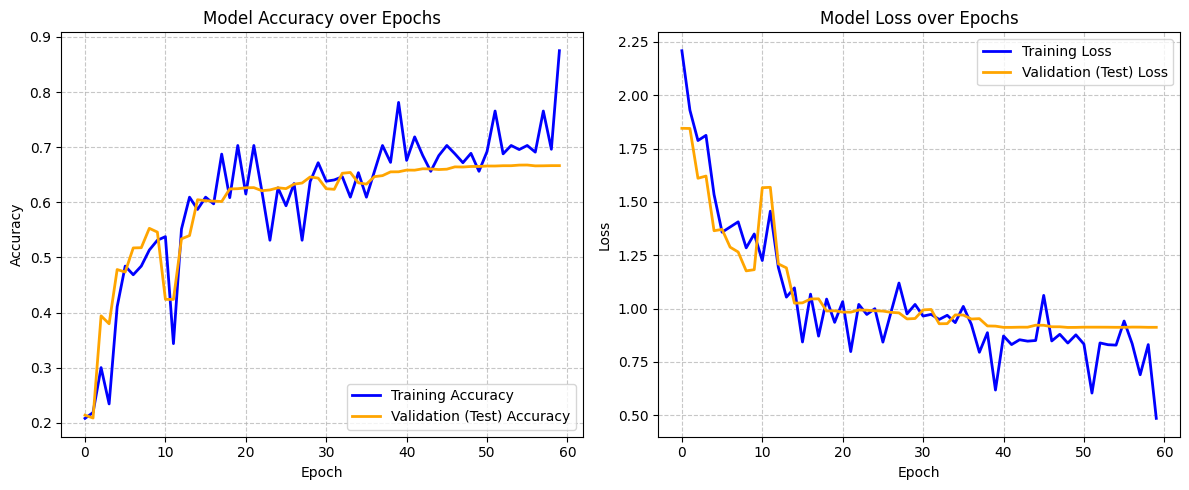

In [ ]:
import matplotlib.pyplot as plt

# Set up the figure size
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation (Test) Accuracy', color='orange', linewidth=2)
plt.title('Model Accuracy over Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation (Test) Loss', color='orange', linewidth=2)
plt.title('Model Loss over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

# Display the graphs
plt.tight_layout()
plt.show()